In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: xlabel='Slip (m)', ylabel='Depth (m)'>,
        <Axes: xlabel='Distance from fault (m)', ylabel='Horizontal displacement (m)'>],
       dtype=object))

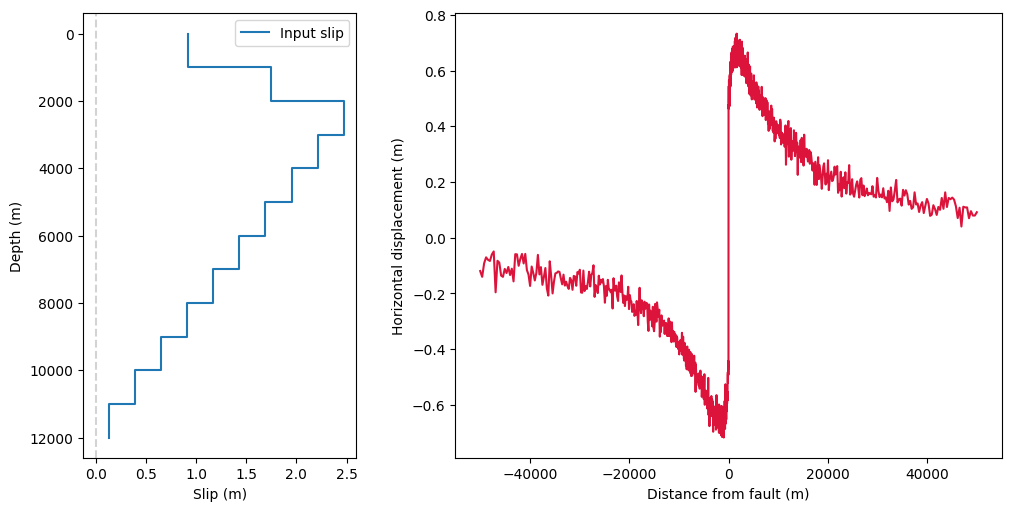

In [2]:
from codes import TwoDDzForwardModel
import numpy as np

model = TwoDDzForwardModel()
n_patches = 12
model = model.build_uniform_patches(n_patches, 12000.)
model = model.gen_triangular_slip_distribution(max_slip_fractional_depth=0.20)
# xs = np.linspace(-40000, 40000, 800)
# xs = np.geomspace(1, 50000, num=1000)
stretch = 4  # increase for stronger tail stretching

xs = np.linspace(-1, 1, 1000)
xs = 50000 * np.sinh(stretch * xs) / np.sinh(stretch)

model = model.run(xs)
noise_lvl = 0.03
model = model.add_gaussian_noise(std=noise_lvl)

model.plot()

In [ ]:
import numpy as np
from codes import HamiltonianInversion, UniformDist

data = model.sol
data_covariance = noise_lvl**2 * np.eye(xs.size)
model.xs = xs

priors = [UniformDist("dz_halfwidth", 0., 1000.)] + [UniformDist(f"slip{i}", 0., 10.) for i in range(n_patches)]

inversion = HamiltonianInversion(model, priors, data, data_covariance)
inversion = inversion.run()

Starting inversion...
Linear estimation of gradient in Greens function (13)
p0 p1 p2 p3 p4 p5 p6 p7 p8 p9 p10 p11 p12 
... estimation complete:
Cholesky factorisation...
... factorisation complete.


/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/blockwise.py:514: RuntimeWarning: divide by zero encountered in matmul
  return (core_func(*inputs),)
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/blockwise.py:514: RuntimeWarning: overflow encountered in matmul
  return (core_func(*inputs),)
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/blockwise.py:514: RuntimeWarning: invalid value encountered in matmul
  return (core_func(*inputs),)
Initializing NUTS using jitter+adapt_diag...
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/blockwise.py:514: RuntimeWarning: divide by zero encountered in matmul
  return (core_func(*inputs),)
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/blockwise.py:514: RuntimeWarning: overflow encountered in matmul
  return (core_func(*inputs),)
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/bl

/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 648 seconds.
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/math.py:3026: RuntimeWarning: divide by zero encountered in matmul
  output_storage[0][0] = np.matmul(*inputs)
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/math.py:3026: RuntimeWarning: overflow encountered in matmul
  output_storage[0][0] = np.matmul(*inputs)
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/math.py:3026: RuntimeWarning: invalid value encountered in matmul
  output_storage[0][0] = np.matmul(*inputs)
Sampling: [obs]


/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: title={'center': 'Slip distribution on fault patches'}, xlabel='Slip (m)', ylabel='Depth (m)'>,
        <Axes: title={'center': 'Horizontal surface displacement across strike'}, xlabel='Distance from fault (m)', ylabel='Horizontal displacement (m)'>],
       dtype=object))

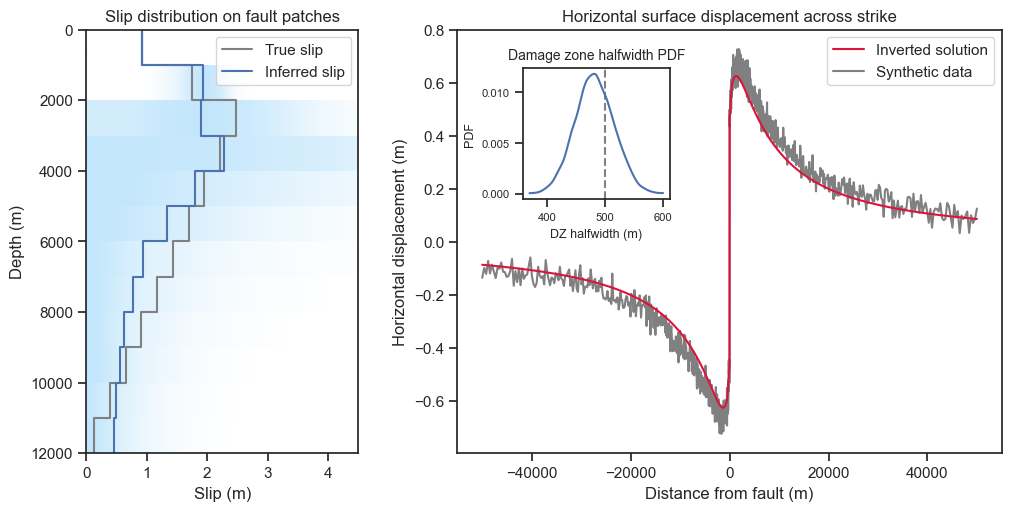

In [46]:
import seaborn as sns
sns.set_theme()
sns.set_style("ticks")
model.plot_inversion_result(inversion.result, data, title=None, true_slips=model.slips, true_dz=500., plot_kwargs={"xlim": (0., 4.5), "axtitles": ["Slip distribution on fault patches", "Horizontal surface displacement across strike"]}, savefig="./results/synthetic_inversion_results.png")

                 mean      sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
dz_halfwidth  986.457  12.791  963.260  999.987      0.194    0.338    2808.0   
slip0          -2.821   0.024   -2.865   -2.774      0.000    0.000    3475.0   
slip1          -9.987   0.014  -10.000   -9.960      0.000    0.000    1885.0   
slip2          -9.939   0.061  -10.000   -9.831      0.001    0.001    2674.0   
slip3          -1.419   0.350   -2.053   -0.746      0.006    0.005    3065.0   
slip4          -0.233   0.226   -0.660   -0.000      0.004    0.005    2826.0   
slip5          -0.212   0.218   -0.610   -0.000      0.003    0.006    2787.0   
slip6          -0.259   0.260   -0.745   -0.000      0.004    0.006    3367.0   
slip7          -0.345   0.343   -0.990   -0.000      0.005    0.009    3323.0   
slip8          -0.487   0.462   -1.348   -0.000      0.007    0.010    3106.0   
slip9          -0.707   0.693   -1.959   -0.000      0.010    0.016    2748.0   
slip10         -1.085   1.01

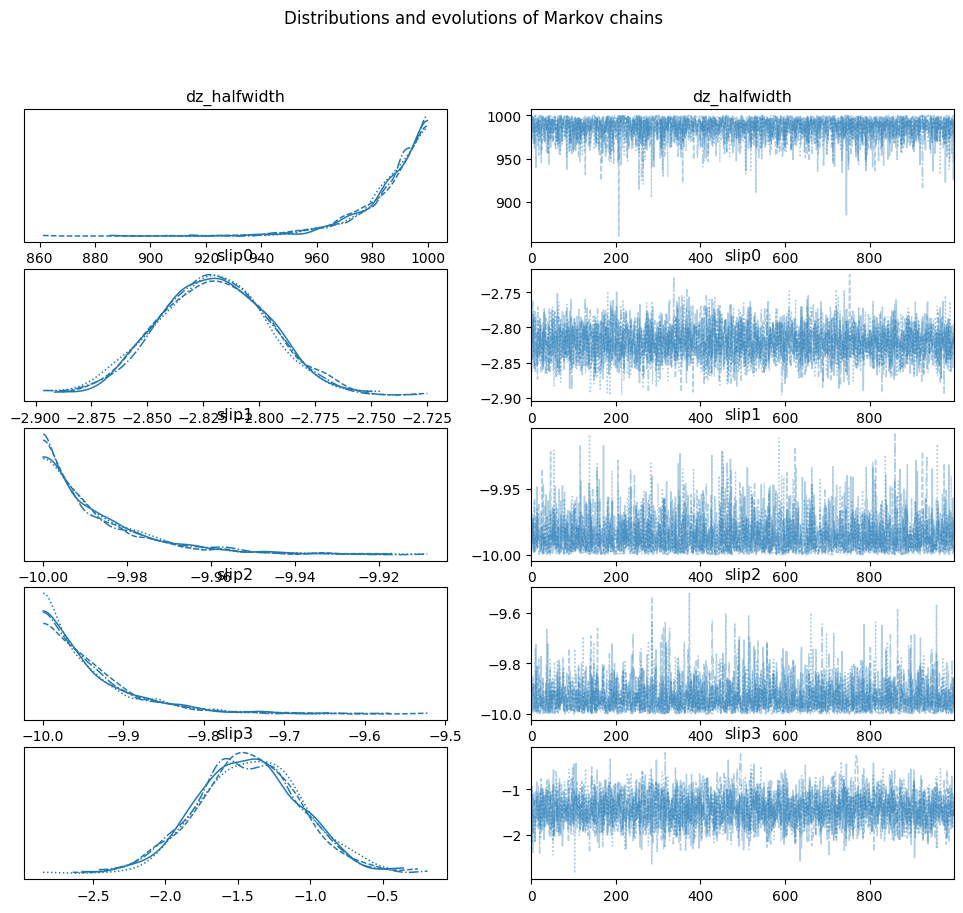

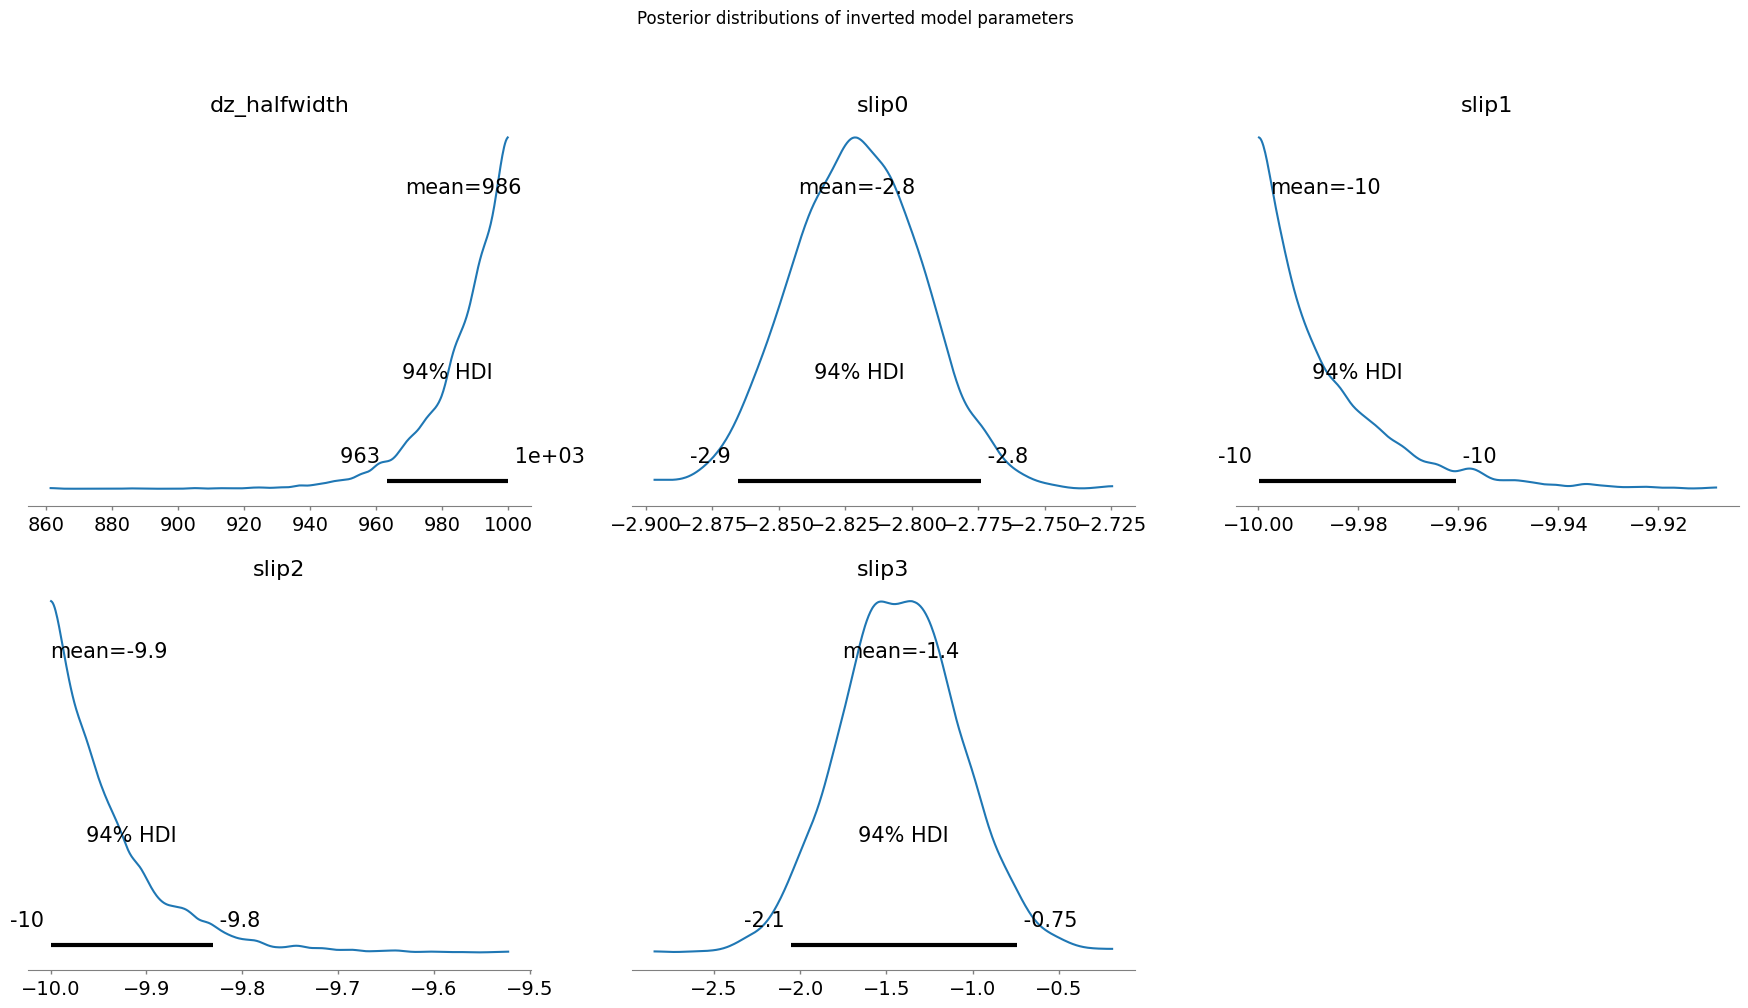

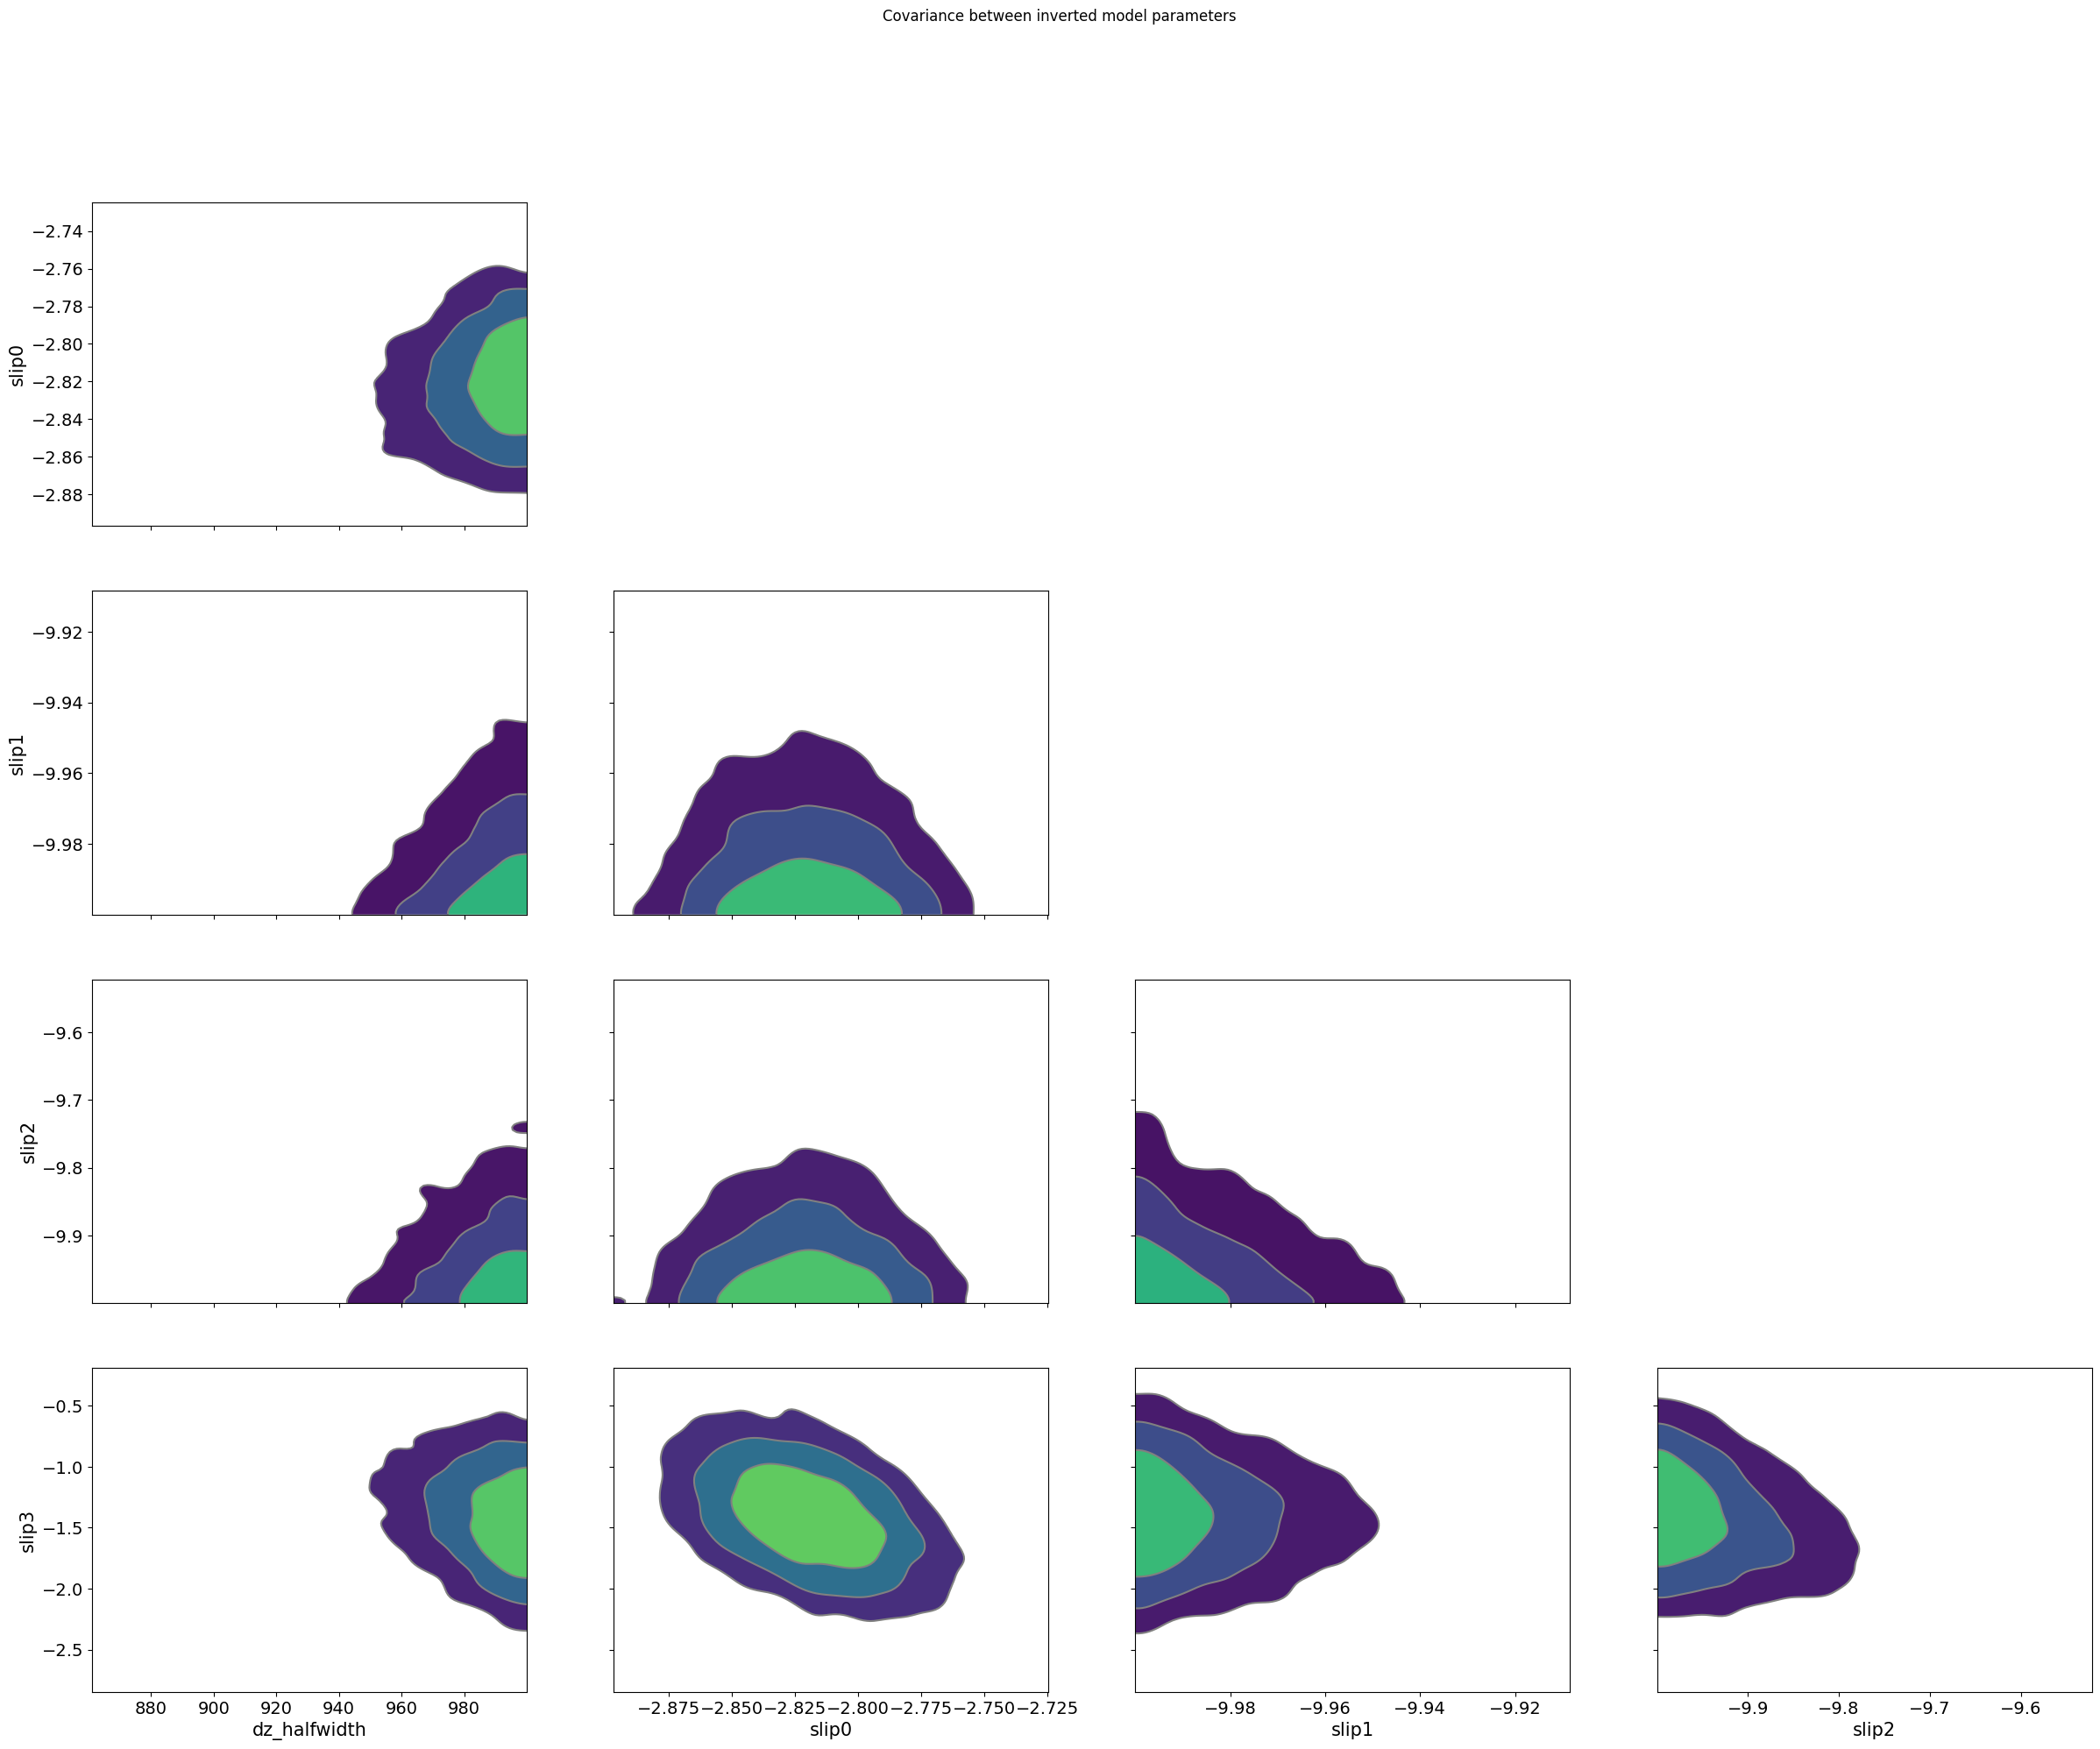

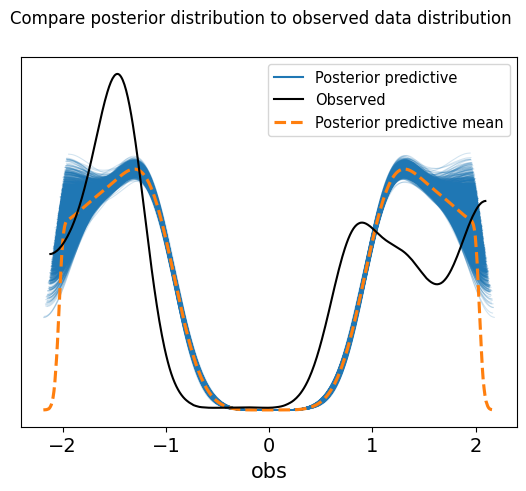

In [7]:
inversion.diagnostics()